In [1]:
import pandas as pd
from rich import print as rprint 
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
import os

# 1M Dataset


# 32M Dataset
rating_file_path = '../../data/mv-lens-32m/ml-32m/ratings.csv'
movies_file_path = '../../data/mv-lens-32m/ml-32m/movies.csv'


if os.path.exists(rating_file_path) and os.path.exists(movies_file_path):
    ratings_df = pd.read_csv(rating_file_path)
    movies_df = pd.read_csv(movies_file_path)
else:
    rprint('file not found!')
    # Execute the download script
    import subprocess
    subprocess.run(['../../start.sh'])
    ratings_df = pd.read_csv(rating_file_path)
    movies_df = pd.read_csv(movies_file_path)
rprint(ratings_df)
rprint(movies_df)



userId  movieId  rating   timestamp
0              1       17     4.0   944249077
1              1       25     1.0   944250228
2              1       29     2.0   943230976
3              1       30     5.0   944249077
4              1       32     5.0   943228858
...          ...      ...     ...         ...
32000199  200948    79702     4.5  1294412589
32000200  200948    79796     1.0  1287216292
32000201  200948    80350     0.5  1294412671
32000202  200948    80463     3.5  1350423800
32000203  200948    87304     4.5  1350423523

[32000204 rows x 4 columns]

movieId                               title  \
0            1                    Toy Story (1995)   
1            2                      Jumanji (1995)   
2            3             Grumpier Old Men (1995)   
3            4            Waiting to Exhale (1995)   
4            5  Father of the Bride Part II (1995)   
...        ...                                 ...   
87580   292731           The Monroy Affaire (2022)   
87581   292737          Shelter in Solitude (2023)   
87582   292753                         Orca (2023)   
87583   292755              The Angry Breed (1968)   
87584   292757           Race to the Summit (2023)   

                                            genres  
0      Adventure|Animation|Children|Comedy|Fantasy  
1                       Adventure|Children|Fantasy  
2                                   Comedy|Romance  
3                             Comedy|Drama|Romance  
4                                           Comedy  
...                                            ...  
87580                                        Drama  
87581                                 Comedy|Drama  
87582                                        Drama  
87583                                        Drama  
87584                 Action|Adventure|Documentary  

[87585 rows x 3 columns]

In [3]:
merged_df = pd.merge(ratings_df, movies_df, on='movieId', how='left')
rprint(merged_df.head())


userId  movieId  rating  timestamp  \
0       1       17     4.0  944249077   
1       1       25     1.0  944250228   
2       1       29     2.0  943230976   
3       1       30     5.0  944249077   
4       1       32     5.0  943228858   

                                               title  \
0                       Sense and Sensibility (1995)   
1                           Leaving Las Vegas (1995)   
2  City of Lost Children, The (Cité des enfants p...   
3  Shanghai Triad (Yao a yao yao dao waipo qiao) ...   
4          Twelve Monkeys (a.k.a. 12 Monkeys) (1995)   

                                   genres  
0                           Drama|Romance  
1                           Drama|Romance  
2  Adventure|Drama|Fantasy|Mystery|Sci-Fi  
3                             Crime|Drama  
4                 Mystery|Sci-Fi|Thriller

In [4]:
merged_df.shape

(32000204, 6)

In [5]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000204 entries, 0 to 32000203
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
 4   title      object 
 5   genres     object 
dtypes: float64(1), int64(3), object(2)
memory usage: 1.4+ GB


In [6]:
merged_df.describe()

,userId,movieId,rating,timestamp
count,3.200020e+07,3.200020e+07,3.200020e+07,3.200020e+07
mean,1.002785e+05,2.931861e+04,3.540396e+00,1.275241e+09
std,5.794905e+04,5.095816e+04,1.058986e+00,2.561630e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,5.005300e+04,1.233000e+03,3.000000e+00,1.051012e+09
50%,1.002970e+05,3.452000e+03,3.500000e+00,1.272622e+09
75%,1.504510e+05,4.419900e+04,4.000000e+00,1.503158e+09
max,2.009480e+05,2.927570e+05,5.000000e+00,1.697164e+09


In [7]:
# Check for missing values
missing_values = merged_df.isnull().sum()
rprint(missing_values)



userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64

In [8]:
merged_df.columns

Index(['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres'], dtype='object')

Ratings column summary:

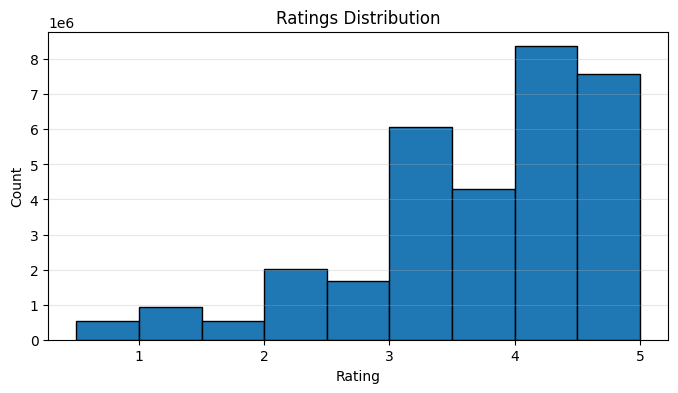

Count of ratings per rating score:

rating
0.5     525132
1.0     946675
1.5     531063
2.0    2028622
2.5    1685386
3.0    6054990
3.5    4290105
4.0    8367654
4.5    2974000
5.0    4596577
Name: count, dtype: int64

In [9]:
# Basic inspection of rating column
rprint("[bold cyan]Ratings column summary:[/bold cyan]")

# Histogram of rating values (0.5 to 5.0, usually in 0.5 steps)
fig , ax = plt.subplots(figsize=(8, 4) )
ax.hist(merged_df['rating'], bins=[x / 2 for x in range(1, 11)], edgecolor='black')
ax.set_title('Ratings Distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
# ax.tight_layout()
plt.show()

# Count of ratings per rating score
rating_counts = merged_df['rating'].value_counts().sort_index()
rprint("[bold cyan]Count of ratings per rating score:[/bold cyan]")
rprint(rating_counts)

Number of ratings per user (first 10 users):

userId
175325    33332
17035      9577
55653      9178
123465     9044
171795     9016
10202      7748
198515     7594
49305      7488
22744      7372
7858       7322
Name: rating, dtype: int64

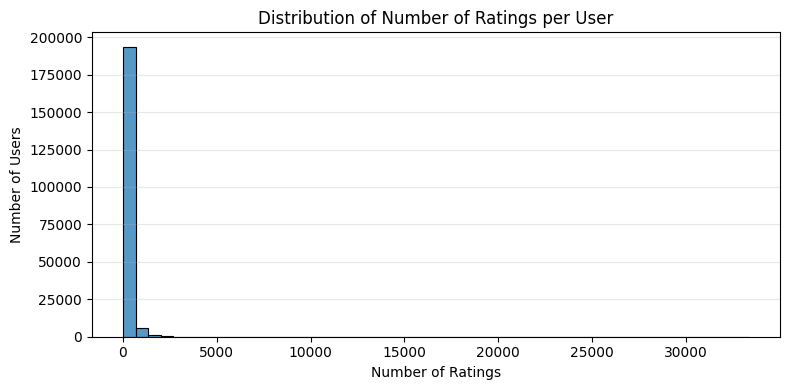

Power users (top 1% by rating count, threshold = 1290 ratings):

userId
175325    33332
17035      9577
55653      9178
123465     9044
171795     9016
10202      7748
198515     7594
49305      7488
22744      7372
7858       7322
14674      6407
53192      6265
133878     6074
57304      6061
129705     5812
139018     5806
43703      5784
68797      5693
103925     5655
119247     5654
Name: rating, dtype: int64

Total number of power users: 2014

Inactive users (<= 5 ratings):

Series([], Name: rating, dtype: int64)

Total number of inactive users: 0

In [10]:
# User Activity Analysis

# Number of ratings per user
user_rating_counts = merged_df.groupby('userId')['rating'].count().sort_values(ascending=False)

rprint("[bold magenta]Number of ratings per user (first 10 users):[/bold magenta]")
rprint(user_rating_counts.head(10))


plt.figure(figsize=(8, 4))
sns.histplot(user_rating_counts, bins=50, kde=False)
plt.title('Distribution of Number of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Identify power users (top X% or above a threshold)
# Here: users in the top 1% by number of ratings
threshold_power = user_rating_counts.quantile(0.99)
power_users = user_rating_counts[user_rating_counts >= threshold_power]

rprint(f"[bold magenta]Power users (top 1% by rating count, threshold = {threshold_power:.0f} ratings):[/bold magenta]")
rprint(power_users.head(20))  # show first 20
rprint(f"Total number of power users: {len(power_users)}")

# Identify inactive users
# Here: users with very few ratings (e.g., <= 5 ratings)
inactive_threshold = 5
inactive_users = user_rating_counts[user_rating_counts <= inactive_threshold]

rprint(f"[bold magenta]Inactive users (<= {inactive_threshold} ratings):[/bold magenta]")
rprint(inactive_users.head(20))  # show first 20
rprint(f"Total number of inactive users: {len(inactive_users)}")

Most-rated movies (top 20):

movieId  title                                                                         
318      Shawshank Redemption, The (1994)                                                  102929
356      Forrest Gump (1994)                                                               100296
296      Pulp Fiction (1994)                                                                98409
2571     Matrix, The (1999)                                                                 93808
593      Silence of the Lambs, The (1991)                                                   90330
260      Star Wars: Episode IV - A New Hope (1977)                                          85010
2959     Fight Club (1999)                                                                  77332
480      Jurassic Park (1993)                                                               75233
527      Schindler's List (1993)                                                            73849
4993     Lord of the Rings: The Fellowship of the Ring, The (2001)                          73122
1196     Star Wars: Episode V - The Empire Strikes Back (1980)                              72151
110      Braveheart (1995)                                                                  69482
1        Toy Story (1995)                                                                   68997
589      Terminator 2: Judgment Day (1991)                                                  68383
50       Usual Suspects, The (1995)                                                         67750
1210     Star Wars: Episode VI - Return of the Jedi (1983)                                  67496
5952     Lord of the Rings: The Two Towers, The (2002)                                      67463
7153     Lord of the Rings: The Return of the King, The (2003)                              67449
1198     Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)     67408
858      Godfather, The (1972)                                                              66440
Name: rating, dtype: int64

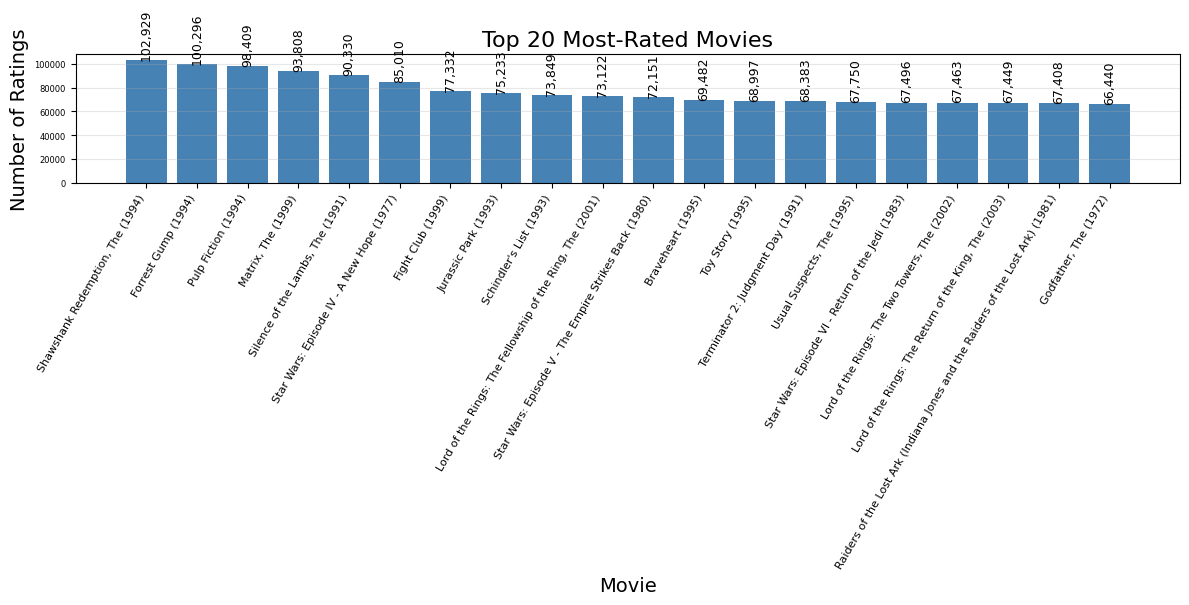

In [11]:
# Movie Popularity Analysis

# Number of ratings per movie
movie_rating_counts = merged_df.groupby(['movieId', 'title'])['rating'].count().sort_values(ascending=False)

rprint("[bold green]Most-rated movies (top 20):[/bold green]")
most_rated_movies = movie_rating_counts.head(20)
rprint(most_rated_movies)

# Prepare data for plotting: extract titles and counts
top20_df = most_rated_movies.reset_index(name='rating_count')

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(top20_df['title'], top20_df['rating_count'], color='steelblue')
ax.set_title('Top 20 Most-Rated Movies', fontsize=16)
ax.set_xlabel('Movie', fontsize=14)
ax.set_ylabel('Number of Ratings', fontsize=14)
ax.tick_params(axis='y', labelsize=6)
ax.set_xticks(range(len(top20_df['title'])))
ax.set_xticklabels(top20_df['title'], rotation=60, ha='right', fontsize=8)

# Add count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height,
            f'{int(height):,}', ha='center', va='bottom', fontsize=9, rotation=90)

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Movie stats (first 10 rows):

movieId                               title  avg_rating  rating_count
0        1                    Toy Story (1995)    3.897438         68997
1        2                      Jumanji (1995)    3.275758         28904
2        3             Grumpier Old Men (1995)    3.139447         13134
3        4            Waiting to Exhale (1995)    2.845331          2806
4        5  Father of the Bride Part II (1995)    3.059602         13154
5        6                         Heat (1995)    3.868277         29490
6        7                      Sabrina (1995)    3.363968         13585
7        8                 Tom and Huck (1995)    3.115563          1510
8        9                 Sudden Death (1995)    2.987723          4154
9       10                    GoldenEye (1995)    3.427850         32474

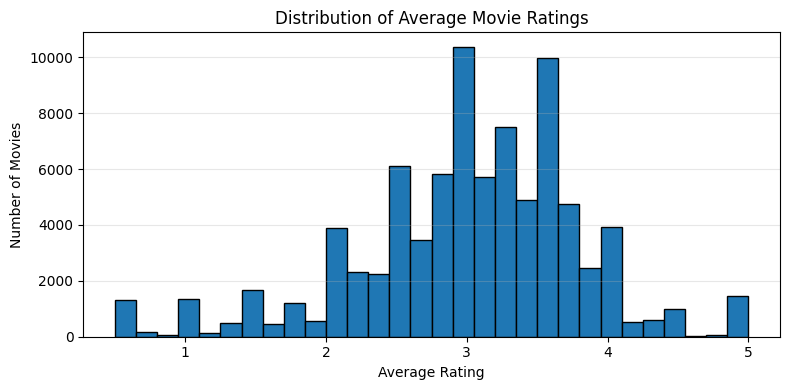

Number of movies with at least 20 ratings: 23350

Top 20 highest-rated movies (>= 20 ratings):

movieId                                              title  avg_rating  \
44190   171011                             Planet Earth II (2016)    4.446830   
39306   159817                                Planet Earth (2006)    4.444369   
44042   170705                            Band of Brothers (2001)    4.426539   
314        318                   Shawshank Redemption, The (1994)    4.404614   
44337   171331       The Work of Director Chris Cunningham (2003)    4.395833   
44416   171495                                             Cosmos    4.330081   
840        858                              Godfather, The (1972)    4.317030   
58698   202439                                    Parasite (2019)    4.312254   
34288   147124         The Roosevelts: An Intimate History (2014)    4.306818   
47975   179135                              Blue Planet II (2017)    4.300086   
56760   198185                                  Twin Peaks (1989)    4.298684   
65936   220528                            Twelve Angry Men (1954)    4.286192   
71289   242210  James Acaster: Cold Lasagne Hate Myself 1999 (...    4.272727   
1173      1203                                12 Angry Men (1957)    4.265311   
49          50                         Usual Suspects, The (1995)    4.265070   
1190      1221                     Godfather: Part II, The (1974)    4.264468   
40994   163809                        Over the Garden Wall (2013)    4.263780   
49605   182723                        Cosmos: A Spacetime Odissey    4.250842   
1930      2019        Seven Samurai (Shichinin no samurai) (1954)    4.249622   
32219   142115                             The Blue Planet (2001)    4.247408   

       rating_count  
44190          1956  
39306          2948  
44042          2811  
314          102929  
44337            24  
44416           615  
840           66440  
58698         11670  
34288            44  
47975          1163  
56760          1140  
65936           449  
71289            22  
1173          21863  
49            67750  
1190          43111  
40994          1397  
49605           594  
1930          16531  
32219          1061

Top 20 lowest-rated movies (>= 20 ratings):

movieId                                              title  avg_rating  \
60326   206190                       6-Headed Shark Attack (2018)    0.860000   
8146      8859                SuperBabies: Baby Geniuses 2 (2004)    0.865759   
7158      7282                           Hip Hop Witch, Da (2000)    0.866667   
32165   141994                            Saving Christmas (2014)    0.871429   
20790   107704                     Justin Bieber's Believe (2013)    0.909091   
48262   179747                                      Crimea (2017)    0.937500   
23792   120222                                  Foodfight! (2012)    0.989130   
6361      6483                        From Justin to Kelly (2003)    1.006356   
4670      4775                                     Glitter (2001)    1.128798   
12034    56835                                Pledge This! (2006)    1.166667   
33484   145096  Barbie & Her Sisters in the Great Puppy Advent...    1.180556   
1740      1826                    Barney's Great Adventure (1998)    1.197727   
6465      6587                                       Gigli (2003)    1.204057   
9607     31698                             Son of the Mask (2005)    1.220553   
24057   121103              Justin Bieber: Never Say Never (2011)    1.238095   
12618    61348                              Disaster Movie (2008)    1.248252   
36065   151913                            The Best Movie 2 (2009)    1.250000   
27334   130398                               Transmorphers (2007)    1.261905   
5628      5739                            Faces of Death 6 (1996)    1.284884   
36424   152755                                Atlantic Rim (2013)    1.300000   

       rating_count  
60326            25  
8146            257  
7158             30  
32165            35  
20790            22  
48262            24  
23792            46  
6361            472  
4670            757  
12034            30  
33484            72  
1740            440  
6465            838  
9607            832  
24057            63  
12618           715  
36065            32  
27334            21  
5628            172  
36424            25

In [12]:
# Movie Average Rating Analysis

# Compute mean rating and rating count per movie
movie_stats = merged_df.groupby(['movieId', 'title'])['rating'].agg(['mean', 'count']).reset_index()
movie_stats.rename(columns={'mean': 'avg_rating', 'count': 'rating_count'}, inplace=True)

rprint("[bold cyan]Movie stats (first 10 rows):[/bold cyan]")
rprint(movie_stats.head(10))    

# Distribution of average ratings
plt.figure(figsize=(8, 4))
plt.hist(movie_stats['avg_rating'], bins=30, edgecolor='black')
plt.title('Distribution of Average Movie Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Number of Movies')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Identify highest-rated movies with a minimum rating-count threshold
min_ratings_threshold = 20
filtered = movie_stats[movie_stats['rating_count'] >= min_ratings_threshold]

rprint(f"[bold cyan]Number of movies with at least {min_ratings_threshold} ratings:[/bold cyan] {len(filtered)}")

# Sort by average rating descending, then by rating_count descending for tie-breaking
highest_rated = filtered.sort_values(by=['avg_rating', 'rating_count'], ascending=[False, False]).head(20)

rprint(f"[bold cyan]Top 20 highest-rated movies (>= {min_ratings_threshold} ratings):[/bold cyan]")
rprint(highest_rated[['movieId', 'title', 'avg_rating', 'rating_count']])

# Identify lowest-rated movies with the same threshold
lowest_rated = filtered.sort_values(by=['avg_rating', 'rating_count'], ascending=[True, False]).head(20)

rprint(f"[bold cyan]Top 20 lowest-rated movies (>= {min_ratings_threshold} ratings):[/bold cyan]")
rprint(lowest_rated[['movieId', 'title', 'avg_rating', 'rating_count']])


Movies per genre:

genre
Drama                 33152
Comedy                22448
Thriller              11555
Romance               10048
Action                 9296
Documentary            9103
Horror                 8468
Crime                  6704
(no genres listed)     6555
Adventure              5156
Sci-Fi                 4797
Animation              4586
Children               4447
Mystery                3894
Fantasy                3784
War                    2225
Western                1489
Musical                1033
Film-Noir               350
IMAX                    195
Name: movieId, dtype: int64

Average rating per genre:

genre
Film-Noir             3.915774
War                   3.791699
Crime                 3.691771
Documentary           3.691182
Drama                 3.682454
Mystery               3.673103
Animation             3.615332
Western               3.600175
IMAX                  3.593312
Musical               3.554277
Romance               3.545003
Thriller              3.531702
Adventure             3.523439
Fantasy               3.512175
Sci-Fi                3.491699
Action                3.476407
Children              3.439241
Comedy                3.432386
(no genres listed)    3.368157
Horror                3.307155
Name: rating, dtype: float64

Genre popularity (by number of ratings):

genre
Drama                 13973271
Comedy                11206926
Action                 9665213
Thriller               8679464
Adventure              7590522
Sci-Fi                 5717337
Romance                5524615
Crime                  5373051
Fantasy                3702759
Children               2731841
Mystery                2615322
Horror                 2492315
Animation              2214562
War                    1594110
IMAX                   1494179
Musical                1159516
Western                 596654
Documentary             427353
Film-Noir               304710
(no genres listed)       55498
Name: rating, dtype: int64

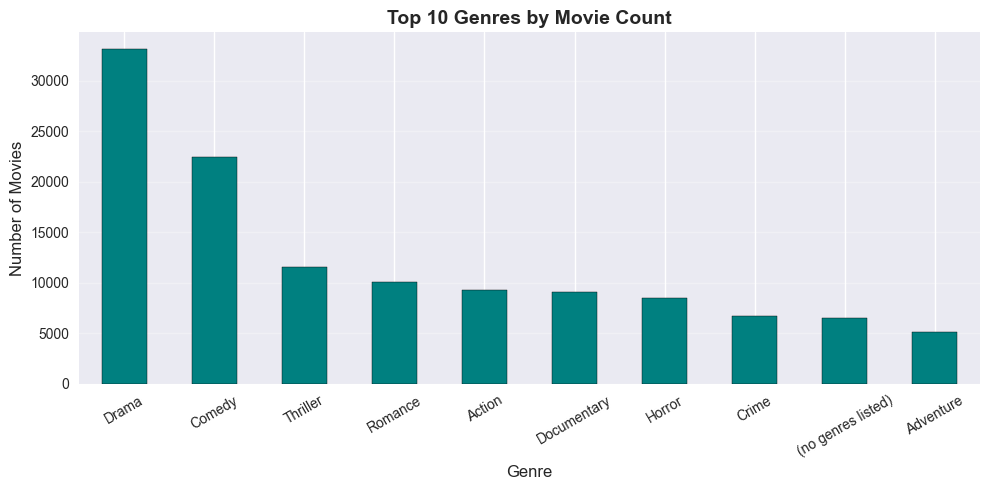

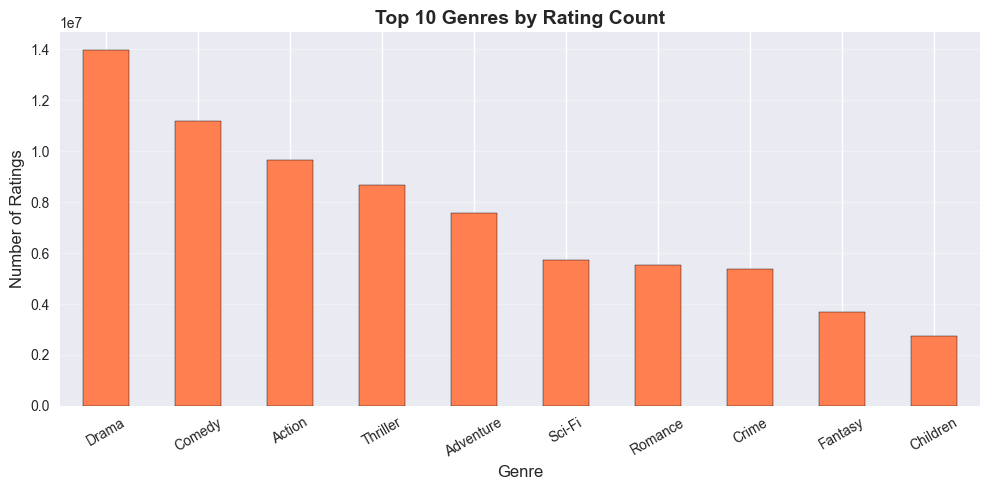

In [13]:
# Genre Analysis

# Split and explode genres
genre_exploded = merged_df.copy()
genre_exploded['genres'] = genre_exploded['genres'].fillna('(no genres listed)')
genre_exploded = genre_exploded.assign(genre=genre_exploded['genres'].str.split('|')).explode('genre')

# Count movies in each genre (unique movie count per genre)
movies_per_genre = genre_exploded.drop_duplicates(['movieId', 'genre']).groupby('genre')['movieId'].count().sort_values(ascending=False)

rprint('[bold yellow]Movies per genre:[/bold yellow]')
rprint(movies_per_genre)

# Average rating per genre
avg_rating_per_genre = genre_exploded.groupby('genre')['rating'].mean().sort_values(ascending=False)

rprint('[bold yellow]Average rating per genre:[/bold yellow]')
rprint(avg_rating_per_genre)

# Popularity of genres (by number of ratings)
genre_popularity = genre_exploded.groupby('genre')['rating'].count().sort_values(ascending=False)

rprint('[bold yellow]Genre popularity (by number of ratings):[/bold yellow]')
rprint(genre_popularity)

# Visualize top 10 genres by movie count (separate figure)
plt.style.use('seaborn-v0_8')
fig1, ax1 = plt.subplots(figsize=(10, 5))
movies_per_genre.head(10).plot(kind='bar', ax=ax1, color='teal', edgecolor='black')
ax1.set_title('Top 10 Genres by Movie Count', fontsize=14, weight='bold')
ax1.set_ylabel('Number of Movies', fontsize=12)
ax1.set_xlabel('Genre', fontsize=12)
ax1.tick_params(axis='x', rotation=30, labelsize=10)
ax1.tick_params(axis='y', labelsize=10)
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Visualize top 10 genres by rating count (separate figure)
fig2, ax2 = plt.subplots(figsize=(10, 5))
genre_popularity.head(10).plot(kind='bar', ax=ax2, color='coral', edgecolor='black')
ax2.set_title('Top 10 Genres by Rating Count', fontsize=14, weight='bold')
ax2.set_ylabel('Number of Ratings', fontsize=12)
ax2.set_xlabel('Genre', fontsize=12)
ax2.tick_params(axis='x', rotation=30, labelsize=10)
ax2.tick_params(axis='y', labelsize=10)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



Ratings count per year:

year
1995          4
1996    1571368
1997     685388
1998     301691
1999    1174629
2000    1912322
2001    1160098
2002     849762
2003    1011000
2004    1139068
2005    1752573
2006    1141704
2007    1023813
2008    1117071
2009     890696
2010     860073
2011     729301
2012     695493
2013     563301
2014     518537
2015    1743866
2016    1918739
2017    1827953
2018    1391057
2019    1385467
2020    1688159
2021    1239912
2022     913105
2023     794054
Name: rating, dtype: int64

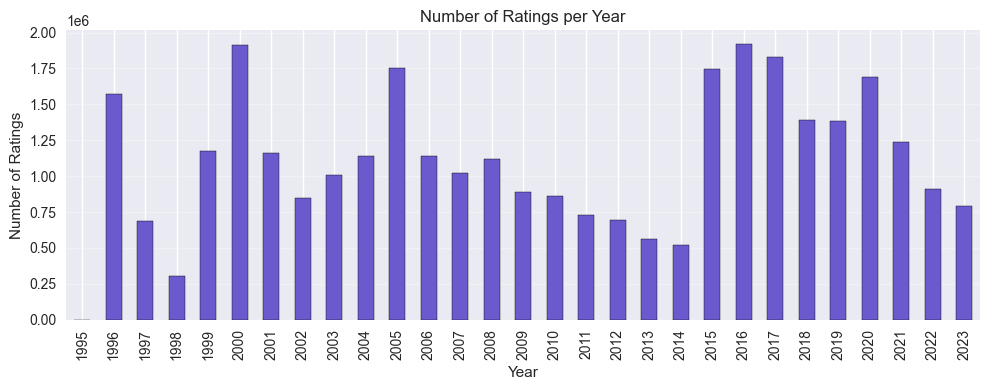

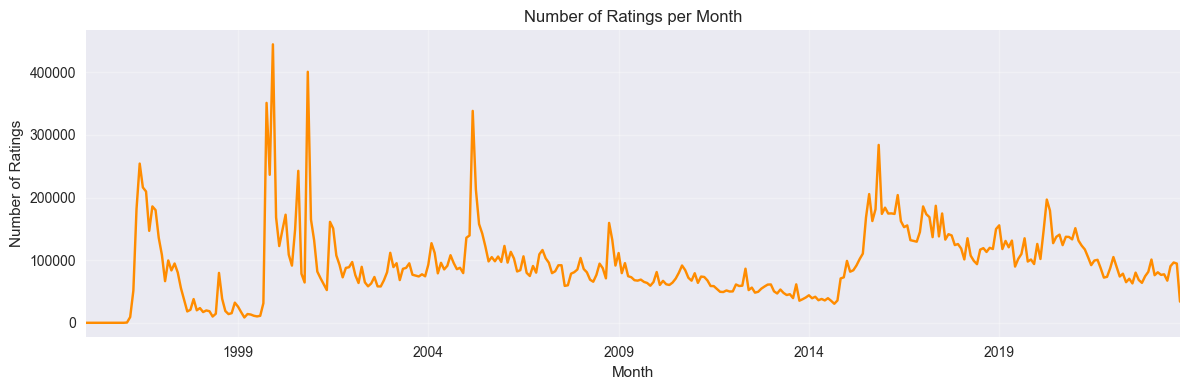

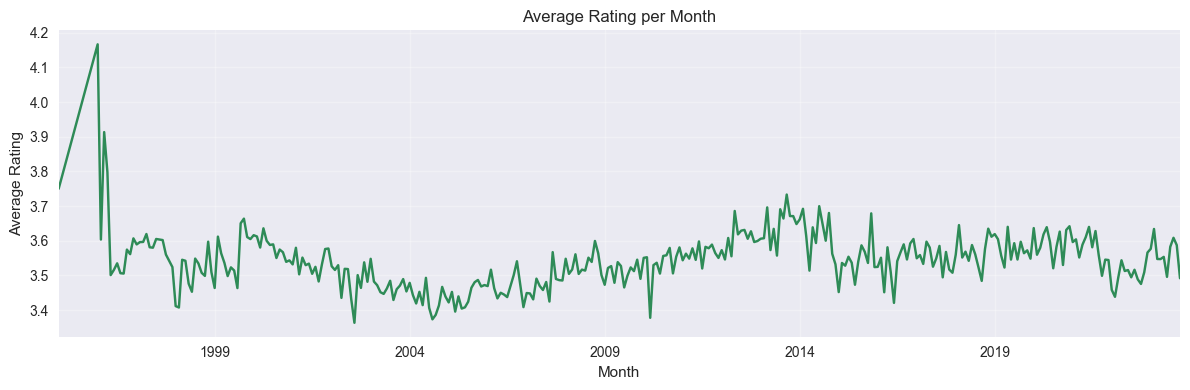

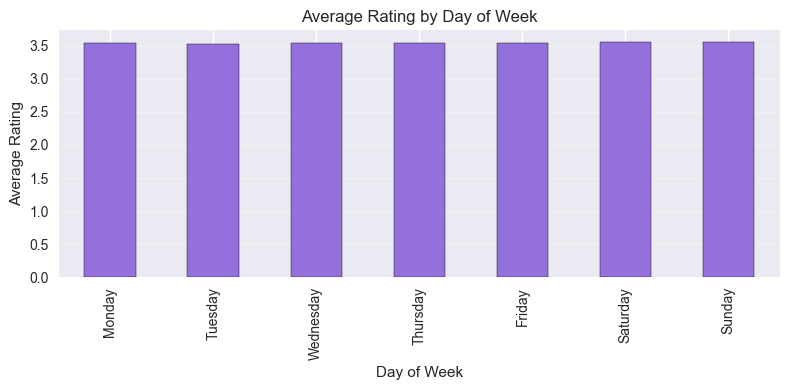

In [14]:
# Ratings Over Time Analysis

# Convert timestamp to datetime if not already
if not pd.api.types.is_datetime64_any_dtype(merged_df['timestamp']):
    ratings_time = merged_df.copy()
    ratings_time['datetime'] = pd.to_datetime(ratings_time['timestamp'], unit='s')
else:
    ratings_time = merged_df.copy()
    ratings_time['datetime'] = ratings_time['timestamp']

ratings_time['year'] = ratings_time['datetime'].dt.year
ratings_time['month'] = ratings_time['datetime'].dt.to_period('M')
ratings_time['date'] = ratings_time['datetime'].dt.date

# 1) Ratings count per year
ratings_per_year = ratings_time.groupby('year')['rating'].count()

rprint('[bold cyan]Ratings count per year:[/bold cyan]')
rprint(ratings_per_year)

plt.figure(figsize=(10, 4))
ratings_per_year.plot(kind='bar', color='slateblue', edgecolor='black')
plt.title('Number of Ratings per Year')
plt.xlabel('Year')
plt.ylabel('Number of Ratings')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Ratings count per month (time series)
ratings_per_month = ratings_time.groupby('month')['rating'].count().sort_index()

plt.figure(figsize=(12, 4))
ratings_per_month.plot(color='darkorange')
plt.title('Number of Ratings per Month')
plt.xlabel('Month')
plt.ylabel('Number of Ratings')
plt.grid(axis='both', alpha=0.3)
plt.tight_layout()
plt.show()

# 3) Average rating over time (by month)
avg_rating_per_month = ratings_time.groupby('month')['rating'].mean().sort_index()

plt.figure(figsize=(12, 4))
avg_rating_per_month.plot(color='seagreen')
plt.title('Average Rating per Month')
plt.xlabel('Month')
plt.ylabel('Average Rating')
plt.grid(axis='both', alpha=0.3)
plt.tight_layout()
plt.show()

# 4) Seasonal trends: average rating by day of week
ratings_time['day_of_week'] = ratings_time['datetime'].dt.day_name()
avg_by_dow = ratings_time.groupby('day_of_week')['rating'].mean()
# Order days of week
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_by_dow = avg_by_dow.reindex(ordered_days)

plt.figure(figsize=(8, 4))
avg_by_dow.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Average Rating by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Rating')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Top 20 most-rated (popular) movies:

movieId                                              title  avg_rating  \
314       318                   Shawshank Redemption, The (1994)    4.404614   
351       356                                Forrest Gump (1994)    4.052744   
292       296                                Pulp Fiction (1994)    4.196969   
2480     2571                                 Matrix, The (1999)    4.156437   
585       593                   Silence of the Lambs, The (1991)    4.148367   
257       260          Star Wars: Episode IV - A New Hope (1977)    4.099824   
2867     2959                                  Fight Club (1999)    4.228780   
475       480                               Jurassic Park (1993)    3.698623   
522       527                            Schindler's List (1993)    4.236990   
4888     4993  Lord of the Rings: The Fellowship of the Ring,...    4.092134   
1166     1196  Star Wars: Episode V - The Empire Strikes Back...    4.130352   
108       110                                  Braveheart (1995)    3.988630   
0           1                                   Toy Story (1995)    3.897438   
581       589                  Terminator 2: Judgment Day (1991)    3.962045   
49         50                         Usual Suspects, The (1995)    4.265070   
1179     1210  Star Wars: Episode VI - Return of the Jedi (1983)    3.991555   
5841     5952      Lord of the Rings: The Two Towers, The (2002)    4.072188   
7029     7153  Lord of the Rings: The Return of the King, The...    4.094360   
1168     1198  Raiders of the Lost Ark (Indiana Jones and the...    4.111893   
840       858                              Godfather, The (1972)    4.317030   

      rating_count  
314         102929  
351         100296  
292          98409  
2480         93808  
585          90330  
257          85010  
2867         77332  
475          75233  
522          73849  
4888         73122  
1166         72151  
108          69482  
0            68997  
581          68383  
49           67750  
1179         67496  
5841         67463  
7029         67449  
1168         67408  
840          66440

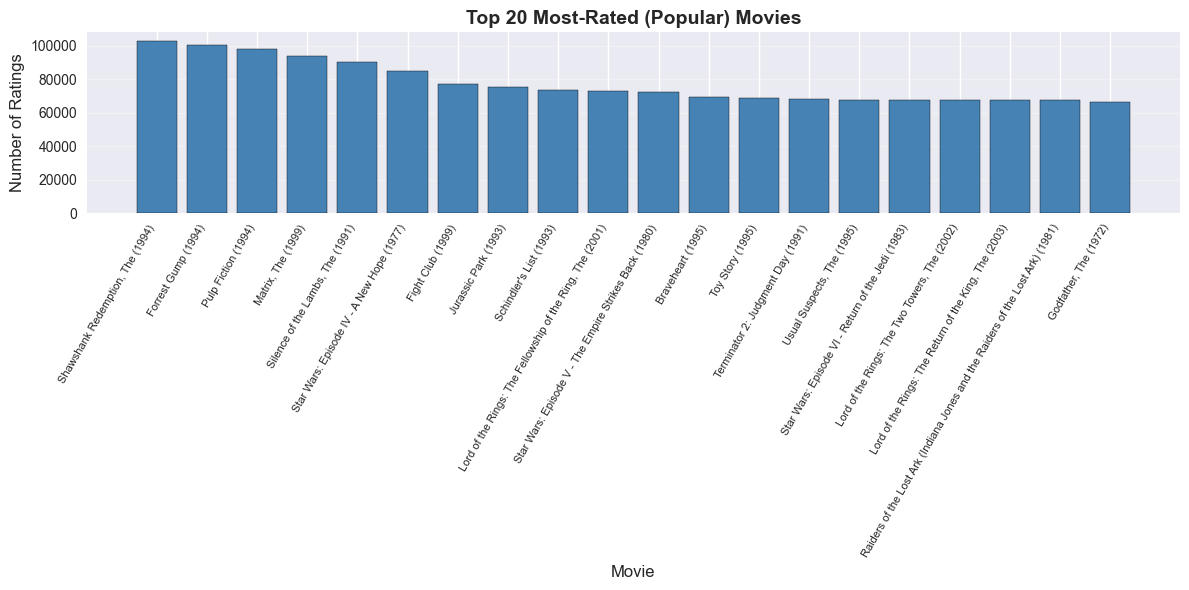

Top 20 highest-rated movies (>= 50 ratings):

movieId                                        title  avg_rating  \
44190   171011                       Planet Earth II (2016)    4.446830   
39306   159817                          Planet Earth (2006)    4.444369   
44042   170705                      Band of Brothers (2001)    4.426539   
314        318             Shawshank Redemption, The (1994)    4.404614   
44416   171495                                       Cosmos    4.330081   
840        858                        Godfather, The (1972)    4.317030   
58698   202439                              Parasite (2019)    4.312254   
47975   179135                        Blue Planet II (2017)    4.300086   
56760   198185                            Twin Peaks (1989)    4.298684   
65936   220528                      Twelve Angry Men (1954)    4.286192   
1173      1203                          12 Angry Men (1957)    4.265311   
49          50                   Usual Suspects, The (1995)    4.265070   
1190      1221               Godfather: Part II, The (1974)    4.264468   
40994   163809                  Over the Garden Wall (2013)    4.263780   
49605   182723                  Cosmos: A Spacetime Odissey    4.250842   
1930      2019  Seven Samurai (Shichinin no samurai) (1954)    4.249622   
32219   142115                       The Blue Planet (2001)    4.247408   
41983   166024                              Whiplash (2013)    4.240097   
522        527                      Schindler's List (1993)    4.236990   
20298   105250              Century of the Self, The (2002)    4.232911   

       rating_count  
44190          1956  
39306          2948  
44042          2811  
314          102929  
44416           615  
840           66440  
58698         11670  
47975          1163  
56760          1140  
65936           449  
1173          21863  
49            67750  
1190          43111  
40994          1397  
49605           594  
1930          16531  
32219          1061  
41983          3080  
522           73849  
20298           395

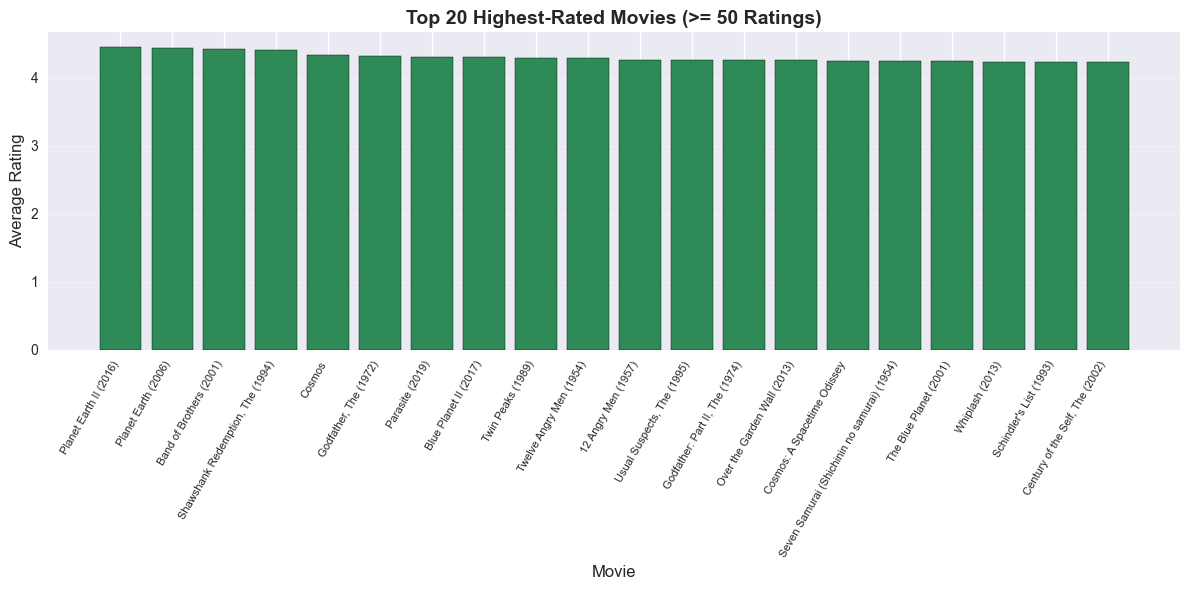

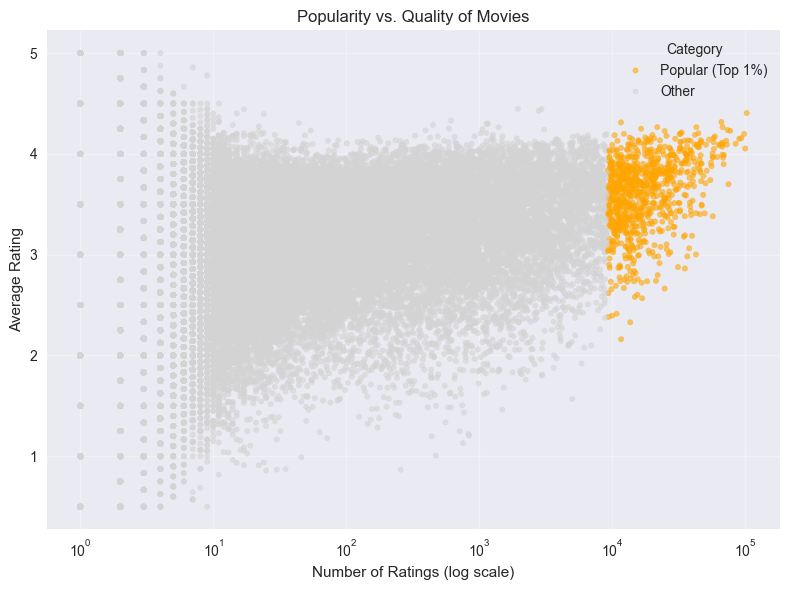

In [15]:
# Popular vs. High Rated Movies Analysis

# Ensure we have per-movie average rating and rating count
# Reuse movie_stats if it exists; otherwise compute
try:
    movie_stats
except NameError:
    movie_stats = merged_df.groupby(['movieId', 'title'])['rating'].agg(['mean', 'count']).reset_index()
    movie_stats.rename(columns={'mean': 'avg_rating', 'count': 'rating_count'}, inplace=True)

# 1) Most-rated (popular) movies
most_rated_overall = movie_stats.sort_values('rating_count', ascending=False).head(20)
rprint('[bold green]Top 20 most-rated (popular) movies:[/bold green]')
rprint(most_rated_overall[['movieId', 'title', 'avg_rating', 'rating_count']])

# Bar plot: Top 20 most-rated movies
fig1, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(most_rated_overall['title'], most_rated_overall['rating_count'], color='steelblue', edgecolor='black')
ax1.set_title('Top 20 Most-Rated (Popular) Movies', fontsize=14, weight='bold')
ax1.set_xlabel('Movie', fontsize=12)
ax1.set_ylabel('Number of Ratings', fontsize=12)
ax1.tick_params(axis='x', labelrotation=60, labelsize=8)
ax1.tick_params(axis='y', labelsize=10)
# Align x tick labels to the right
for label in ax1.get_xticklabels():
    label.set_ha('right')
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Highest-rated movies with a minimum rating-count threshold
min_ratings_threshold = 50
high_quality = movie_stats[movie_stats['rating_count'] >= min_ratings_threshold]
highest_rated_overall = high_quality.sort_values('avg_rating', ascending=False).head(20)

rprint(f'[bold blue]Top 20 highest-rated movies (>= {min_ratings_threshold} ratings):[/bold blue]')
rprint(highest_rated_overall[['movieId', 'title', 'avg_rating', 'rating_count']])

# Bar plot: Top 20 highest-rated movies (with threshold)
fig2, ax2 = plt.subplots(figsize=(12, 6))
ax2.bar(highest_rated_overall['title'], highest_rated_overall['avg_rating'], color='seagreen', edgecolor='black')
ax2.set_title(f'Top 20 Highest-Rated Movies (>= {min_ratings_threshold} Ratings)', fontsize=14, weight='bold')
ax2.set_xlabel('Movie', fontsize=12)
ax2.set_ylabel('Average Rating', fontsize=12)
ax2.tick_params(axis='x', labelrotation=60, labelsize=8)
ax2.tick_params(axis='y', labelsize=10)
# Align x tick labels to the right
for label in ax2.get_xticklabels():
    label.set_ha('right')
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3) Scatter plot: number of ratings vs average rating (with categories)

# Build a small categorical label for hue
popularity_cutoff = movie_stats['rating_count'].quantile(0.99)
movie_stats_plot = movie_stats.copy()
movie_stats_plot['category'] = 'Other'
movie_stats_plot.loc[movie_stats_plot['rating_count'] >= popularity_cutoff, 'category'] = 'Popular (Top 1%)'
movie_stats_plot.loc[(movie_stats_plot['rating_count'] >= min_ratings_threshold) &
                     (movie_stats_plot['avg_rating'] >= 4.5), 'category'] = 'High-rated (>=4.5 & >= threshold)'

plt.figure(figsize=(8, 6))
sns.scatterplot(data=movie_stats_plot,
                x='rating_count', y='avg_rating',
                hue='category', palette={'Other': 'lightgray',
                                         'Popular (Top 1%)': 'orange',
                                         'High-rated (>=4.5 & >= threshold)': 'red'},
                alpha=0.6, s=15, edgecolor=None)

plt.xscale('log')
plt.xlabel('Number of Ratings (log scale)')
plt.ylabel('Average Rating')
plt.title('Popularity vs. Quality of Movies')
plt.grid(alpha=0.3)
plt.legend(title='Category')
plt.tight_layout()
plt.show()


## Analysis: Popularity vs. Quality Scatter Plot

The scatter plot visualizes the relationship between **how many ratings a movie receives** (popularity) and its **average rating** (quality). Each point represents a movie, with the x-axis on a **logarithmic scale** to accommodate the large spread in rating counts.

- **Overall pattern**: Most movies cluster at the **low-to-moderate rating-count region** with average ratings roughly between **3.0 and 4.0**, indicating that the majority of movies receive a modest number of ratings and are rated around the middle of the scale.
- **Popular movies (Top 1%)**: Movies highlighted as **“Popular (Top 1%)”** appear on the **far right** of the plot (high rating counts). These titles typically have **tens of thousands of ratings** but their average ratings still tend to sit in a **narrow band around 3.8–4.3**, showing that extreme popularity does not necessarily imply extremely high or low ratings.
- **High-rated movies (>= 4.5 & rating-count threshold)**: The **high-rated** category tends to appear in the **upper region of the plot**, often with **fewer ratings than the most popular titles**, but still above the reliability threshold (to avoid single-vote noise). This suggests that some movies are **critically well-received** yet **not as broadly rated** as mainstream blockbusters.
- **Variance at low counts**: On the **left side** (low rating counts), the spread of average ratings is **much wider**, with some movies rated very high or very low. This reflects that with **fewer ratings, averages are more volatile** and less reliable.
- **Stability at high counts**: As we move to the **right** (high rating counts), the cloud of points **compresses vertically**, meaning that movies with many ratings tend to have **more stable, less extreme averages**, usually between **3 and 4.5**.

Overall, the scatter plot reveals that **popularity and quality are related but distinct dimensions**: the most popular movies are generally well-liked, but not necessarily the absolute highest-rated, while some of the highest-rated movies may remain relatively niche compared to blockbuster titles.


In [16]:
num_ratings = len(ratings_df)
num_users = ratings_df['userId'].nunique()
num_movies = ratings_df['movieId'].nunique()

density = num_ratings / (num_users * num_movies)
sparsity = 1 - density

print("Users:", num_users)
print("Movies:", num_movies)
print("Ratings:", num_ratings)
print("Density:", density)
print("Sparsity:", sparsity)


Users: 200948
Movies: 84432
Ratings: 32000204
Density: 0.0018860881306254364
Sparsity: 0.9981139118693746
